# Vision Transformers: From ViT to ViTAEv2
### Understanding how attention and convolution work together for image recognition

An English, step-by-step tutorial by **Maram Alzahrani**.

**Paper:** Qiming Zhang, Yufei Xu, Jing Zhang, and Dacheng Tao. *ViTAEv2: Vision Transformer Advanced by Exploring Inductive Bias for Image Recognition and Beyond.* [arXiv:2202.10108v2](https://arxiv.org/abs/2202.10108v2), 2022.

**Scope:** Learn the original ViT pipeline, then explore the paper's locality and multi-scale ideas with small PyTorch examples. The final hybrid model is an **educational illustration**, not an implementation or reproduction of ViTAEv2. No benchmark results are claimed.

[Official implementation](https://github.com/ViTAE-Transformer/ViTAE-Transformer)

Run cells in order. The core tutorial uses synthetic images, runs on CPU, and needs no downloaded dataset. The optional final experiment uses CIFAR-10.

## 1. What is a Vision Transformer?

A Vision Transformer (ViT) splits an image into patches, converts each patch into a vector, and lets the patches exchange information through self-attention.

A patch is a small image region. A token is its vector representation. A model can learn relationships between distant regions, rather than only nearby pixels.

**Pipeline:** Image → patches → patch embeddings → position information → Transformer encoder → classification head.

<img src="assets/vit_pipeline.svg" width="950" alt="Vision Transformer pipeline">

## 2. Setup

Python 3.10+ is recommended. Install the packages once, then restart the kernel if needed. A GPU is optional. `torchvision` is needed only for the optional CIFAR-10 experiment.

In [1]:
# Uncomment if these packages are not installed:
# %pip install torch torchvision numpy matplotlib

import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| Device:", device)

PyTorch: 2.14.1+cpu | Device: cpu


## 3. Turn an Image into Patches

For a 32 × 32 image with 8 × 8 patches, there are (32 / 8)² = **16 patches**. Each RGB patch contains 8 × 8 × 3 = **192 values**.

The synthetic image below contains colored regions and stripes. It is for understanding shapes, not evaluating recognition performance.

Image: (1, 3, 32, 32) | Patches: (1, 16, 192)


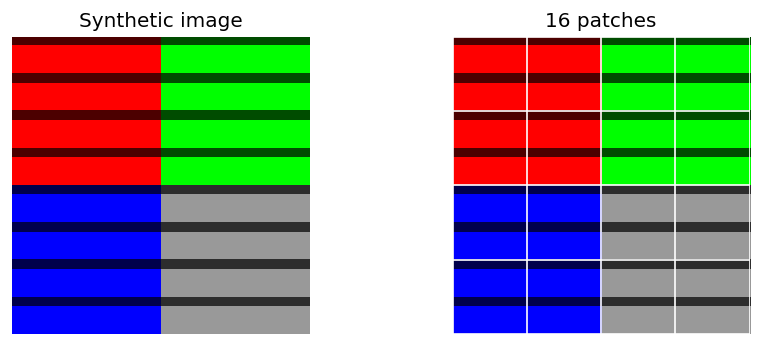

In [2]:
image = torch.zeros(1, 3, 32, 32)
image[:, 0, :16, :16] = 1.0
image[:, 1, :16, 16:] = 1.0
image[:, 2, 16:, :16] = 1.0
image[:, :, 16:, 16:] = 0.6
image[:, :, ::4, :] *= 0.3
patch_size = 8
# unfold returns [batch, channels * patch_height * patch_width, patch_count].
patches = nn.functional.unfold(image, kernel_size=patch_size, stride=patch_size)
patches = patches.transpose(1, 2)
print("Image:", tuple(image.shape), "| Patches:", tuple(patches.shape))
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(image[0].permute(1, 2, 0)); axes[0].set_title("Synthetic image")
axes[1].imshow(image[0].permute(1, 2, 0)); axes[1].set_title("16 patches")
for edge in range(0, 33, patch_size):
    axes[1].axhline(edge - 0.5, color="white", linewidth=1)
    axes[1].axvline(edge - 0.5, color="white", linewidth=1)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Patch Embeddings

A learned projection maps each flattened patch to a vector of dimension D. A Conv2d with kernel size and stride equal to the patch size performs the same projection efficiently.

**Shapes:** [B, 3, 32, 32] → [B, 64, 4, 4] → [B, 16, 64].

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size=8, embed_dim=64):
        super().__init__()
        self.projection = nn.Conv2d(3, embed_dim, patch_size, stride=patch_size)

    def forward(self, x):
        return self.projection(x).flatten(2).transpose(1, 2)

patch_embed = PatchEmbedding()
tokens = patch_embed(image)
print("Tokens:", tuple(tokens.shape))

Tokens: (1, 16, 64)


## 5. Position Embeddings and the CLS Token

Attention alone does not encode patch order. Position embeddings tell the model where each patch belongs.

The **CLS token** is an extra learned token used to aggregate information for classification. Some image architectures use average pooling instead; CLS is not mandatory for every vision transformer.

In [4]:
cls_token = nn.Parameter(torch.zeros(1, 1, 64))
position = nn.Parameter(torch.randn(1, 17, 64) * 0.02)
sequence = torch.cat([cls_token.expand(tokens.size(0), -1, -1), tokens], dim=1)
sequence = sequence + position
print("16 patch tokens + 1 CLS token:", tuple(sequence.shape))

16 patch tokens + 1 CLS token: (1, 17, 64)


## 6. How Self-Attention Works

Each token produces a Query (Q), Key (K), and Value (V). Q · K measures compatibility. Scaling by √D keeps scores manageable; softmax turns scores into weights. Weighted values form the output.

**Attention(Q, K, V) = softmax(QKᵀ / √D)V**

Multi-head attention repeats this idea across several learned subspaces.

Attention weights: (1, 17, 17)
Output: (1, 17, 64)


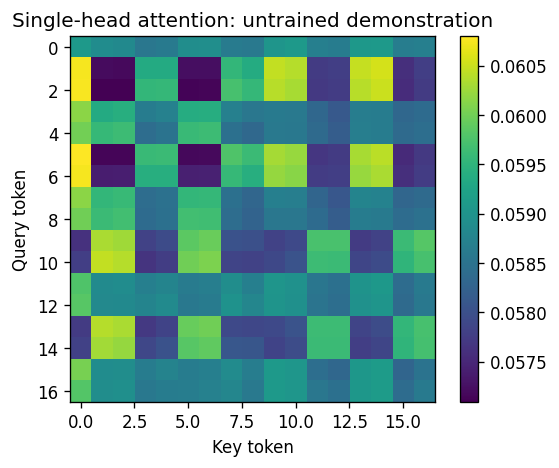

In [5]:
qkv = nn.Linear(64, 3 * 64)
q, k, v = qkv(sequence).chunk(3, dim=-1)
scores = q @ k.transpose(-2, -1) / (q.size(-1) ** 0.5)
weights = scores.softmax(dim=-1)
attended = weights @ v
print("Attention weights:", tuple(weights.shape))
print("Output:", tuple(attended.shape))
assert torch.allclose(weights.sum(-1), torch.ones_like(weights.sum(-1)), atol=1e-6)
plt.figure(figsize=(5, 4))
plt.imshow(weights[0].detach().numpy(), cmap="viridis")
plt.xlabel("Key token"); plt.ylabel("Query token")
plt.title("Single-head attention: untrained demonstration")
plt.colorbar(); plt.tight_layout(); plt.show()

## 7. A Small ViT Classifier

A Transformer encoder combines self-attention, a feed-forward network, normalization, and residual connections. Residual connections preserve a direct path for features and gradients.

This small ViT accepts 32 × 32 images. It starts with random weights and is not a pretrained model.

In [6]:
class TinyViT(nn.Module):
    def __init__(self, image_size=32, patch_size=8, embed_dim=64,
                 depth=2, heads=4, num_classes=10):
        super().__init__()
        if image_size % patch_size:
            raise ValueError("Image size must be divisible by patch size.")
        self.image_size = image_size
        self.embedding = PatchEmbedding(patch_size, embed_dim)
        count = (image_size // patch_size) ** 2
        self.cls = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.position = nn.Parameter(torch.randn(1, count + 1, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim * 4,
            dropout=0.1, activation="gelu", batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, depth, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        if x.shape[-2:] != (self.image_size, self.image_size):
            raise ValueError("Unexpected input image size.")
        x = self.embedding(x)
        x = torch.cat([self.cls.expand(x.size(0), -1, -1), x], dim=1)
        x = self.encoder(x + self.position)
        return self.head(self.norm(x[:, 0]))

vit = TinyViT()
vit.eval()
with torch.no_grad():
    logits = vit(image)
print("Class logits:", tuple(logits.shape))
print("Parameters:", sum(p.numel() for p in vit.parameters()))

Class logits: (1, 10)
Parameters: 114250


## 8. Why Add Inductive Bias?

An **inductive bias** is a built-in assumption that helps a model learn. Convolution naturally emphasizes nearby pixels and reuses filters across locations. Standard ViT must learn much of this spatial structure from data.

The paper explores two useful biases:

| Bias | Meaning | Paper mechanism |
|---|---|---|
| Locality | Nearby pixels contain useful related information | Parallel Convolutional Module (PCM) |
| Multi-scale context | Useful patterns appear at different sizes | Pyramid Reduction Module (PRM) |

Multi-scale context encourages robustness to scale variation; it does not mathematically guarantee exact scale invariance.

## 9. ViTAE and ViTAEv2 in the Paper

**Reduction Cell (RC):** reduces spatial resolution. Its PRM uses convolutions with different dilation rates to build multi-scale context for attention; a parallel PCM adds local context. Branch outputs are fused before a feed-forward network.

**Normal Cell (NC):** maintains spatial resolution and combines attention with a parallel convolution branch. The vanilla ViTAE classification path uses a CLS token; that token is excluded from the spatial convolution branch.

**ViTAEv2:** reorganizes RCs and NCs into four stages, with reduction factors **4, 2, 2, 2**. Early-stage local window attention reduces computation. Later stages model broader dependencies. These stages provide features at different resolutions for downstream tasks.

Our small model below illustrates local + multi-scale + attention fusion. It omits the original RC/NC designs, four-stage configuration, window attention, and official training recipe.

## 10. Explore Multi-scale Convolution

Dilation spaces out the positions sampled by a filter. A 3 × 3 filter with dilation rates 1, 2, and 3 has effective receptive-field sizes 3, 5, and 7 (before accounting for other layers).

We keep spatial dimensions aligned with matching padding, concatenate branches, and project the result back to D channels. This is inspired by PRM, not the exact paper module.

Multi-scale feature map: (1, 64, 8, 8)


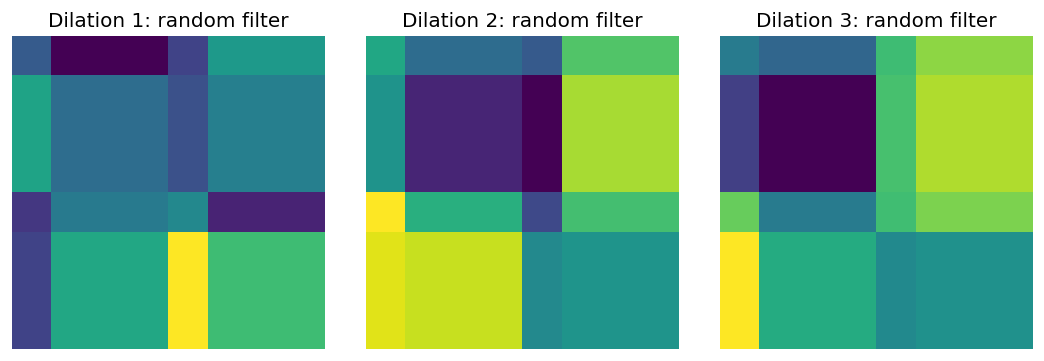

In [7]:
class MultiScaleEmbedding(nn.Module):
    def __init__(self, embed_dim=64, stride=4):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Conv2d(3, embed_dim, 3, stride=stride, padding=d, dilation=d)
            for d in (1, 2, 3)
        ])
        self.fuse = nn.Conv2d(embed_dim * 3, embed_dim, 1)

    def forward(self, x):
        return self.fuse(torch.cat([branch(x) for branch in self.branches], dim=1))

multi_scale = MultiScaleEmbedding()
features = multi_scale(image)
print("Multi-scale feature map:", tuple(features.shape))
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, branch, dilation in zip(axes, multi_scale.branches, (1, 2, 3)):
    ax.imshow(branch(image)[0, 0].detach().numpy(), cmap="viridis")
    ax.set_title(f"Dilation {dilation}: random filter"); ax.axis("off")
plt.tight_layout(); plt.show()

## 11. Combine Local Convolution and Global Attention

The local branch uses convolution over a 2D feature map. The attention branch reshapes that map into a token sequence. Both return [B, D, H, W], allowing element-wise fusion.

This block uses full attention, a residual connection, and an MLP. Its design is deliberately smaller than the paper's modules.

In [8]:
class LocalGlobalBlock(nn.Module):
    def __init__(self, dim=64, heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attention = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.local = nn.Sequential(
            nn.Conv2d(dim, dim, 3, padding=1, groups=dim),
            nn.GELU(), nn.Conv2d(dim, dim, 1))
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 4), nn.GELU(),
                                 nn.Linear(dim * 4, dim))

    def forward(self, x, return_attention=False):
        b, c, h, w = x.shape
        tokens = x.flatten(2).transpose(1, 2)
        normalized = self.norm1(tokens)
        global_out, attention = self.attention(
            normalized, normalized, normalized,
            need_weights=return_attention, average_attn_weights=True)
        local_out = self.local(x).flatten(2).transpose(1, 2)
        fused = tokens + global_out + local_out
        fused = fused + self.mlp(self.norm2(fused))
        output = fused.transpose(1, 2).reshape(b, c, h, w)
        return (output, attention) if return_attention else output

block = LocalGlobalBlock()
print("Fused feature map:", tuple(block(features).shape))

Fused feature map: (1, 64, 8, 8)


## 12. Build the Educational Hybrid Classifier

This model uses multi-scale embedding, two local/global blocks, global average pooling, and a classification head. Average pooling replaces a CLS token in this example.

**Name:** EducationalHybrid. It is not ViTAEv2 and cannot load the official ViTAEv2 checkpoints.

In [9]:
class EducationalHybrid(nn.Module):
    def __init__(self, embed_dim=64, depth=2, heads=4, num_classes=10):
        super().__init__()
        self.embedding = MultiScaleEmbedding(embed_dim, stride=4)
        self.blocks = nn.ModuleList([LocalGlobalBlock(embed_dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x.mean(dim=(2, 3))))

hybrid = EducationalHybrid()
hybrid.eval()
with torch.no_grad():
    print("Hybrid logits:", tuple(hybrid(image).shape))
print("Parameters:", sum(p.numel() for p in hybrid.parameters()))

Hybrid logits: (1, 10)
Parameters: 128074


## 13. Inspect an Attention Map

The next plot shows how one spatial query weights the 8 × 8 feature grid. It uses **random, untrained weights**. It is not evidence that the model found an object, and an attention plot alone is not a faithful explanation of a prediction.

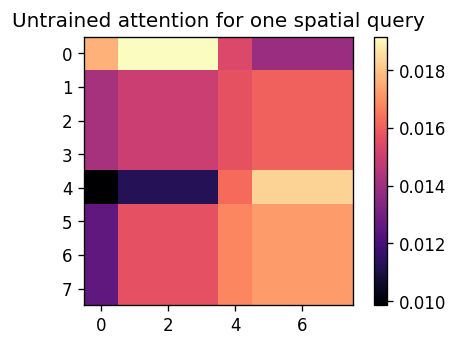

In [10]:
hybrid.eval()
with torch.no_grad():
    embedded = hybrid.embedding(image)
    _, attention = hybrid.blocks[0](embedded, return_attention=True)
h, w = embedded.shape[-2:]
query_index = (h // 2) * w + (w // 2)
attention_map = attention[0, query_index].reshape(h, w).cpu().numpy()
plt.figure(figsize=(4, 3))
plt.imshow(attention_map, cmap="magma")
plt.title("Untrained attention for one spatial query")
plt.colorbar(); plt.tight_layout(); plt.show()

## 14. Check Forward and Backward Passes

A shape check verifies that each model returns one logit per class. A backward pass checks that learning signals reach model parameters. Synthetic labels below are only a software check.

In [11]:
for name, model in [("TinyViT", vit), ("EducationalHybrid", hybrid)]:
    model.train()
    model.zero_grad(set_to_none=True)
    batch = torch.rand(2, 3, 32, 32)
    labels = torch.tensor([0, 1])
    outputs = model(batch)
    assert outputs.shape == (2, 10)
    loss = nn.functional.cross_entropy(outputs, labels)
    loss.backward()
    gradients = [p.grad for p in model.parameters() if p.requires_grad]
    assert all(g is not None and torch.isfinite(g).all() for g in gradients)
    print(name, "forward/backward passed; synthetic loss:", round(loss.item(), 4))

TinyViT forward/backward passed; synthetic loss: 1.9916
EducationalHybrid forward/backward passed; synthetic loss: 2.1412


## 15. Optional: Train Both Models on CIFAR-10

Enable this section only when ready to download data. The default is **3 epochs**, **2,000 training images**, and **500 validation images** from the official training set, with a stratified split. These are quick learning runs, not a reproduction of the paper or a reliable ranking of architectures.

Both models use the same split, optimizer, batch size, and epoch count. Parameter counts, token counts, and embedding designs differ, so this is not a controlled ablation of convolution. TinyViT uses 16 spatial tokens; the hybrid uses 64. Full attention has quadratic token cost.

The official CIFAR-10 test set is evaluated only after selecting a model by validation accuracy. Model selection never uses test performance.

In [12]:
RUN_CIFAR10 = False
EPOCHS = 3
BATCH_SIZE = 64
TRAIN_PER_CLASS = 200
VAL_PER_CLASS = 50

if RUN_CIFAR10:
    from torchvision import datasets, transforms
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])
    eval_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])
    train_source = datasets.CIFAR10("data", train=True, download=True, transform=train_transform)
    val_source = datasets.CIFAR10("data", train=True, download=False, transform=eval_transform)
    test_source = datasets.CIFAR10("data", train=False, download=True, transform=eval_transform)
    rng = np.random.default_rng(SEED)
    targets = np.array(train_source.targets)
    train_ids, val_ids = [], []
    for label in range(10):
        ids = rng.permutation(np.flatnonzero(targets == label))
        train_ids.extend(ids[:TRAIN_PER_CLASS].tolist())
        val_ids.extend(ids[TRAIN_PER_CLASS:TRAIN_PER_CLASS + VAL_PER_CLASS].tolist())
    assert not set(train_ids) & set(val_ids)
    def make_train_loader():
        return DataLoader(torch.utils.data.Subset(train_source, train_ids),
            batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
            generator=torch.Generator().manual_seed(SEED))
    val_loader = DataLoader(torch.utils.data.Subset(val_source, val_ids),
                            batch_size=BATCH_SIZE, num_workers=0)
    test_loader = DataLoader(test_source, batch_size=BATCH_SIZE, num_workers=0)
    print("Train:", len(train_ids), "Validation:", len(val_ids), "Test:", len(test_source))
else:
    print("Optional dataset training is disabled. Core tutorial is complete.")

Optional dataset training is disabled. Core tutorial is complete.


### Training, Validation, and Model Selection

Training updates weights. Validation chooses the best checkpoint and model. Testing estimates final performance on unseen test data. We reset seeds for each run and save the selected validation checkpoint.

Softmax values are model scores; they should not be treated as calibrated probabilities without calibration checks.

In [13]:
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, count = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = nn.functional.cross_entropy(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            count += labels.size(0)
            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
    return total_loss / count, correct / count

if RUN_CIFAR10:
    results, best_states = {}, {}
    factories = {"TinyViT": TinyViT, "EducationalHybrid": EducationalHybrid}
    for name, factory in factories.items():
        random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
        model = factory().to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
        train_loader = make_train_loader()
        best_accuracy, history = -1.0, []
        for epoch in range(EPOCHS):
            train_loss, train_acc = run_epoch(model, train_loader, optimizer)
            val_loss, val_acc = run_epoch(model, val_loader)
            history.append((train_loss, val_loss, train_acc, val_acc))
            if val_acc > best_accuracy:
                best_accuracy = val_acc
                best_states[name] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print(f"{name} | epoch {epoch + 1}/{EPOCHS} | train {train_acc:.3f} | val {val_acc:.3f}")
        results[name] = {"best_validation_accuracy": best_accuracy,
                         "parameters": sum(p.numel() for p in model.parameters()), "history": history}
    selected_name = max(results, key=lambda name: results[name]["best_validation_accuracy"])
    selected_model = factories[selected_name]().to(device)
    selected_model.load_state_dict(best_states[selected_name])
    test_loss, test_accuracy = run_epoch(selected_model, test_loader)
    print("Selected:", selected_name, "| Test accuracy:", round(test_accuracy, 4))
    torch.save({"model_name": selected_name, "state_dict": best_states[selected_name],
                "classes": train_source.classes, "seed": SEED,
                "test_accuracy": test_accuracy}, "educational_classifier.pt")

### Visualize the Learning Curves

Inspect validation behavior instead of judging a model only by training accuracy. A large training/validation gap may indicate overfitting. With very short runs, both models may still be undertrained.

In [14]:
if RUN_CIFAR10:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for name, result in results.items():
        history = np.array(result["history"])
        epochs = np.arange(1, len(history) + 1)
        axes[0].plot(epochs, history[:, 1], marker="o", label=name)
        axes[1].plot(epochs, history[:, 3], marker="o", label=name)
    axes[0].set_title("Validation loss"); axes[1].set_title("Validation accuracy")
    for ax in axes:
        ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

## 16. What Does the Paper Evaluate?

The paper studies image classification on **ImageNet**, object detection on **MS COCO**, semantic segmentation on **ADE20K**, and pose estimation on **AP10K**. Those are the authors' experiments; this notebook implements only an educational classification workflow.

Its reported **88.5% ImageNet Top-1** and **91.2% ImageNet-ReaL Top-1** concern the scaled-up 644M-parameter ViTAE model under the paper's training setup. They are not results from this notebook, nor the accuracy of every ViTAEv2 variant.

Ablation studies examine architectural choices such as multi-scale branches, local convolution, feature fusion, and stage-wise attention. A proper ablation changes one factor while controlling the others.

## 17. What to Remember

- ViT represents an image as a sequence of patch tokens.
- Position information preserves spatial ordering; attention models token relationships.
- ViTAE introduces local convolution and multi-scale context into Transformer designs.
- ViTAEv2 uses a multi-stage feature hierarchy and early window attention.
- The compact hybrid here demonstrates the idea and does not reproduce the paper.
- Random-weight visualizations illustrate computation, not recognition ability.
- A short CIFAR-10 run cannot establish the paper's claims or a general architecture ranking.

## References

1. Zhang et al. (2022). [ViTAEv2: Vision Transformer Advanced by Exploring Inductive Bias for Image Recognition and Beyond](https://arxiv.org/abs/2202.10108v2). Primary source for this tutorial.
2. [Official ViTAE / ViTAEv2 code](https://github.com/ViTAE-Transformer/ViTAE-Transformer). Consult it for exact modules, variants, and training configurations.
3. Dosovitskiy et al. (2021). [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://arxiv.org/abs/2010.11929). Original ViT paper.

**Source version:** uploaded arXiv v2, dated 27 November 2022. This tutorial does not claim to reproduce published experiments.